In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')
from itertools import combinations
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

In [2]:
tickers = [
    'PETR4', 'VALE3', 'ITUB4', 'PRIO3', 'BBDC4', 'B3SA3', 'AXIA3', 'SBSP3', 
    'BBAS3', 'BPAC11', 'ITSA4', 'RENT3', 'ABEV3', 'WEGE3', 'EQTL3', 'ENEV3', 
    'RDOR3', 'SUZB3', 'LREN3', 'VBBR3', 'RADL3', 'GGBR4', 'BRAV3', 'CSMG3', 
    'TOTS3', 'CMIG4', 'RAIL3', 'CYRE3', 'CSAN3', 'VIVT3', 'UGPA3', 'CURY3', 
    'BBSE3', 'ALOS3', 'HAPV3', 'ENGI11', 'TIMS3', 'USIM5', 'CPFE3', 'MULT3', 
    'KLBN11', 'MBRF3', 'DIRR3', 'MGLU3', 'PSSA3', 'HYPE3', 'CEAB3', 'EGIE3', 
    'TAEE11', 'SANB11'
]

tickers_yfinance = [f"{ticker}.SA" for ticker in tickers]

dados_brutos = yf.download(
    tickers = tickers_yfinance,
    start="2024-01-01",
    end="2024-12-31",
    auto_adjust=True
)

df_fechamento  = dados_brutos['Close'].copy()
df_fechamento  = df_fechamento.ffill()        # ffill no fechamento
df_consolidado = np.log(df_fechamento)        # log em cima do ffill

df_consolidado.columns = [col.replace('.SA', '') for col in df_consolidado.columns]
df_consolidado.index   = df_consolidado.index.strftime('%Y-%m-%d')

print("\n--- Processamento Concluído ---")
print(f"Período : {df_consolidado.index[0]} → {df_consolidado.index[-1]}")
print(f"Matriz  : {df_consolidado.shape[0]} dias x {df_consolidado.shape[1]} ações.")
df_consolidado

[*********************100%***********************]  50 of 50 completed


--- Processamento Concluído ---
Período : 2024-01-02 → 2024-12-30
Matriz  : 251 dias x 50 ações.


,ABEV3,ALOS3,AXIA3,B3SA3,BBAS3,BBDC4,BBSE3,BPAC11,BRAV3,CEAB3,...,SUZB3,TAEE11,TIMS3,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-02,2.501214,3.044111,3.603947,2.570297,3.164307,2.620887,3.259802,3.556930,3.240729,1.930519,...,3.956243,3.420413,2.676238,3.459971,3.163349,2.177657,4.132127,2.906033,3.106578,3.525987
2024-01-03,2.493158,3.044111,3.602748,2.567470,3.165219,2.622020,3.255366,3.538222,3.253716,1.930519,...,3.961849,3.426688,2.677366,3.458758,3.161466,2.172166,4.126922,2.915565,3.093379,3.533614
2024-01-04,2.496828,3.023313,3.594076,2.538024,3.154581,2.608193,3.262454,3.526287,3.233397,1.895333,...,3.946585,3.418482,2.660320,3.432319,3.159957,2.156627,4.113393,2.881797,3.083315,3.520228
2024-01-05,2.493158,3.023710,3.592380,2.556082,3.166496,2.629751,3.253586,3.547474,3.246097,1.892574,...,3.936277,3.423815,2.645890,3.437911,3.182723,2.154387,4.100483,2.899920,3.065059,3.509444
2024-01-08,2.501214,3.035138,3.587521,2.578029,3.175023,2.622020,3.248824,3.579095,3.291695,1.941101,...,3.949145,3.418482,2.654573,3.444396,3.171591,2.147638,4.095380,2.899920,3.055505,3.511943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-20,2.440632,2.813316,3.445154,2.274761,3.116406,2.328055,3.410073,3.325184,3.025022,2.190220,...,4.066454,3.393370,2.557363,3.294674,2.708594,1.691939,3.876598,2.761531,3.089842,3.960144
2024-12-23,2.439814,2.796633,3.431435,2.273787,3.109740,2.310036,3.408978,3.296585,2.945180,2.128890,...,4.093263,3.361957,2.550673,3.299750,2.695754,1.656321,3.880800,2.748116,3.056878,3.937896
2024-12-26,2.433246,2.786264,3.437460,2.280587,3.121378,2.317798,3.408429,3.292997,3.009458,2.087705,...,4.104629,3.369598,2.531945,3.287377,2.673351,1.665818,3.883713,2.741628,3.064756,3.945609


In [ ]:
# Criando a matriz de correlação


matriz_correlacao = df_consolidado.corr()

# Mostra a matriz com um degradê de cores (estilo heatmap)

matriz_correlacao.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

,ABEV3,ALOS3,AXIA3,B3SA3,BBAS3,BBDC4,BBSE3,BPAC11,BRAV3,CEAB3,CMIG4,CPFE3,CSAN3,CSMG3,CURY3,CYRE3,DIRR3,EGIE3,ENEV3,ENGI11,EQTL3,GGBR4,HAPV3,HYPE3,ITSA4,ITUB4,KLBN11,LREN3,MBRF3,MGLU3,MULT3,PETR4,PRIO3,PSSA3,RADL3,RAIL3,RDOR3,RENT3,SANB11,SBSP3,SUZB3,TAEE11,TIMS3,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3
ABEV3,1.00,0.34,0.43,0.42,0.24,0.61,0.40,0.37,-0.33,-0.17,0.06,0.30,0.07,0.31,0.02,0.32,0.09,-0.32,0.10,0.15,0.42,0.27,-0.16,-0.11,0.24,0.29,0.03,0.68,0.22,0.06,0.59,0.11,-0.12,0.25,0.12,0.07,0.23,0.14,0.26,0.28,0.34,0.55,0.32,0.35,0.02,-0.16,0.23,0.19,0.69,0.18
ALOS3,0.34,1.00,0.78,0.78,0.63,0.73,-0.09,0.85,0.08,-0.24,-0.30,0.59,0.71,-0.08,0.10,0.82,-0.10,0.31,0.65,0.79,0.87,-0.42,0.67,0.66,0.46,0.39,-0.51,0.45,-0.39,0.57,0.89,-0.44,0.33,-0.29,0.67,0.68,0.28,0.66,0.73,-0.02,-0.22,0.38,0.60,0.62,0.59,0.28,0.38,0.66,0.42,-0.22
AXIA3,0.43,0.78,1.00,0.87,0.77,0.55,-0.09,0.85,0.34,-0.35,-0.47,0.62,0.74,-0.26,-0.13,0.81,-0.28,0.07,0.47,0.83,0.78,-0.46,0.53,0.71,0.32,0.29,-0.39,0.40,-0.51,0.72,0.76,-0.35,0.53,-0.44,0.52,0.73,0.07,0.66,0.64,-0.10,-0.02,0.16,0.71,0.46,0.75,0.46,0.29,0.70,0.44,-0.35
B3SA3,0.42,0.78,0.87,1.00,0.63,0.57,-0.18,0.87,0.44,-0.55,-0.58,0.78,0.81,-0.36,-0.33,0.69,-0.49,0.09,0.39,0.88,0.74,-0.51,0.56,0.74,0.09,0.04,-0.51,0.27,-0.58,0.77,0.75,-0.43,0.51,-0.58,0.59,0.76,0.03,0.74,0.64,-0.28,-0.19,0.28,0.51,0.58,0.76,0.47,0.41,0.51,0.21,-0.51
BBAS3,0.24,0.63,0.77,0.63,1.00,0.56,0.13,0.69,0.20,-0.05,-0.13,0.37,0.51,0.03,0.20,0.67,0.00,0.30,0.61,0.68,0.65,-0.33,0.59,0.57,0.57,0.52,-0.25,0.44,-0.31,0.46,0.58,-0.07,0.41,-0.23,0.42,0.53,0.32,0.35,0.71,0.14,-0.16,0.19,0.80,0.28,0.58,0.25,0.05,0.82,0.48,-0.12
BBDC4,0.61,0.73,0.55,0.57,0.56,1.00,0.30,0.60,-0.25,-0.00,0.11,0.37,0.31,0.32,0.33,0.60,0.18,0.22,0.69,0.46,0.70,-0.09,0.47,0.29,0.56,0.54,-0.21,0.81,-0.00,0.13,0.83,-0.11,0.16,0.15,0.48,0.26,0.52,0.34,0.74,0.34,-0.01,0.66,0.65,0.40,0.22,-0.16,0.29,0.58,0.67,0.18
BBSE3,0.40,-0.09,-0.09,-0.18,0.13,0.30,1.00,-0.26,-0.59,0.27,0.82,-0.49,-0.63,0.81,0.73,-0.21,0.81,0.22,0.14,-0.41,0.10,0.45,-0.21,-0.56,0.62,0.71,0.61,0.46,0.81,-0.67,0.08,0.57,-0.32,0.75,-0.02,-0.29,0.68,-0.67,0.17,0.85,0.23,0.49,0.18,-0.08,-0.63,-0.80,-0.48,0.19,0.62,0.87
BPAC11,0.37,0.85,0.85,0.87,0.69,0.60,-0.26,1.00,0.38,-0.30,-0.53,0.71,0.82,-0.26,-0.19,0.85,-0.40,0.06,0.42,0.86,0.76,-0.43,0.58,0.73,0.24,0.18,-0.54,0.36,-0.59,0.79,0.79,-0.44,0.49,-0.50,0.64,0.76,0.06,0.80,0.63,-0.18,-0.14,0.26,0.62,0.59,0.80,0.50,0.38,0.66,0.28,-0.48
BRAV3,-0.33,0.08,0.34,0.44,0.20,-0.25,-0.59,0.38,1.00,-0.38,-0.68,0.46,0.59,-0.69,-0.60,0.21,-0.73,-0.00,-0.12,0.53,0.06,-0.44,0.37,0.65,-0.48,-0.50,-0.22,-0.46,-0.72,0.74,-0.06,-0.35,0.74,-0.79,0.34,0.62,-0.48,0.54,0.07,-0.57,-0.13,-0.29,0.07,-0.04,0.71,0.71,0.11,0.17,-0.56,-0.75
CEAB3,-0.17,-0.24,-0.35,-0.55,-0.05,-0.00,0.27,-0.30,-0.38,1.00,0.60,-0.55,-0.52,0.45,0.58,0.04,0.58,0.04,0.08,-0.46,-0.30,0.51,-0.18,-0.44,0.41,0.42,0.47,0.39,0.48,-0.47,-0.25,0.27,-0.18,0.66,-0.23,-0.48,0.25,-0.37,-0.16,0.48,0.38,0.10,0.11,-0.29,-0.36,-0.29,-0.25,0.14,0.22,0.55


In [ ]:
# Cria uma lista para armazenar os resultados
resultados_integracao = []

# Loop para testar cada ação dentro do DataFrame consolidado
for coluna in df_consolidado.columns:
    serie_nivel = df_consolidado[coluna].dropna()
    serie_diff = df_consolidado[coluna].diff().dropna()
    
    # 1. Teste de Dickey-Fuller Aumentado (ADF) em NÍVEL
    # Usamos maxlag='AIC' para que o algoritmo escolha o número ideal de lags automaticamente
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    p_valor_nivel = adf_nivel[1]
    
    # 2. Teste ADF na PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    p_valor_diff = adf_diff[1]
    
    # 3. Lógica para determinar a Ordem de Integração
    # Se o p-valor for menor ou igual a 0.05, rejeitamos H0 (a série é estacionária)
    if p_valor_nivel <= 0.05:
        ordem = "I(0) - Estacionária em nível"
    elif p_valor_diff <= 0.05:
        ordem = "I(1) - Integrada de ordem 1"
    else:
        ordem = "I(2) ou superior"
        
    # Guardando os dados na lista
    resultados_integracao.append({
        'Ativo': coluna,
        'p-valor (Nível)': round(p_valor_nivel, 4),
        'Estacionária em Nível?': 'Sim' if p_valor_nivel <= 0.05 else 'Não',
        'p-valor (1ª Dif)': round(p_valor_diff, 4),
        'Estacionária em 1ª Dif?': 'Sim' if p_valor_diff <= 0.05 else 'Não',
        'Ordem de Integração': ordem
    })

# Transformando os resultados em um DataFrame para visualização limpa
df_resultado_final = pd.DataFrame(resultados_integracao)
df_resultado_final

,Ativo,p-valor (Nível),Estacionária em Nível?,p-valor (1ª Dif),Estacionária em 1ª Dif?,Ordem de Integração
0,ABEV3,0.1700,Não,0.0000,Sim,I(1) - Integrada de ordem 1
1,ALOS3,0.6088,Não,0.0000,Sim,I(1) - Integrada de ordem 1
2,AXIA3,0.5095,Não,0.0000,Sim,I(1) - Integrada de ordem 1
3,B3SA3,0.2403,Não,0.0000,Sim,I(1) - Integrada de ordem 1
4,BBAS3,0.2316,Não,0.0000,Sim,I(1) - Integrada de ordem 1
5,BBDC4,0.4765,Não,0.0000,Sim,I(1) - Integrada de ordem 1
6,BBSE3,0.7234,Não,0.0000,Sim,I(1) - Integrada de ordem 1
7,BPAC11,0.7416,Não,0.0000,Sim,I(1) - Integrada de ordem 1
8,BRAV3,0.7347,Não,0.0000,Sim,I(1) - Integrada de ordem 1
9,CEAB3,0.1913,Não,0.0000,Sim,I(1) - Integrada de ordem 1


In [5]:
cesta_definitiva = df_consolidado.drop(columns=['TAEE11', 'TOTS3', 'VALE3'])

resultados_estacionariedade = []

for coluna in cesta_definitiva.columns:
    serie_nivel = cesta_definitiva[coluna].dropna()
    serie_diff = serie_nivel.diff().dropna()
    
    # 1. TESTES EM NÍVEL
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    kpss_nivel = kpss(serie_nivel, regression='c', nlags="auto")
    
    # 2. TESTES NA PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    kpss_diff = kpss(serie_diff, regression='c', nlags="auto")
    
    # Armazenando os p-valores
    resultados_estacionariedade.append({
        'Ativo': coluna,
        'ADF Nível (p-valor)': round(adf_nivel[1], 4),
        'KPSS Nível (p-valor)': round(kpss_nivel[1], 4),
        'ADF 1ª Dif (p-valor)': round(adf_diff[1], 4),
        'KPSS 1ª Dif (p-valor)': round(kpss_diff[1], 4)
    })

# Convertendo em DataFrame para exibição
df_testes_estatisticos = pd.DataFrame(resultados_estacionariedade)
df_testes_estatisticos

,Ativo,ADF Nível (p-valor),KPSS Nível (p-valor),ADF 1ª Dif (p-valor),KPSS 1ª Dif (p-valor)
0,ABEV3,0.1700,0.0518,0.0000,0.1000
1,ALOS3,0.6088,0.0376,0.0000,0.1000
2,AXIA3,0.5095,0.0100,0.0000,0.1000
3,B3SA3,0.2403,0.0100,0.0000,0.1000
4,BBAS3,0.2316,0.1000,0.0000,0.1000
5,BBDC4,0.4765,0.1000,0.0000,0.1000
6,BBSE3,0.7234,0.0100,0.0000,0.1000
7,BPAC11,0.7416,0.0100,0.0000,0.1000
8,BRAV3,0.7347,0.0100,0.0000,0.1000
9,CEAB3,0.1913,0.0100,0.0000,0.1000


In [6]:
# Usa a cesta_definitiva da célula anterior (já sem as I(0))
# e remove adicionalmente as que falharam no KPSS
colunas_remover = [col for col in ['ABEV3', 'BBAS3', 'BBDC4', 'ENEV3', 'EQTL3', 'LREN3', 'MULT3', 'RADL3', 'SANB11', 'SUZB3', 'TIMS3', 'VBBR3'] if col in cesta_definitiva.columns]

cesta_johansen = cesta_definitiva.drop(columns=colunas_remover)

ativos         = cesta_johansen.columns
todos_os_pares = list(combinations(ativos, 2))
resultados_pares = []

for at1, at2 in todos_os_pares:
    df_par = cesta_johansen[[at1, at2]].dropna()
    res    = coint_johansen(df_par, det_order=0, k_ar_diff=1)

    traco_r0     = res.lr1[0];  vc_traco  = res.cvt[0, 1]
    eigen_r0     = res.lr2[0];  vc_eigen  = res.cvm[0, 1]

    cointegra_traco = traco_r0 > vc_traco
    cointegra_eigen = eigen_r0 > vc_eigen

    beta_at2 = np.round(res.evec[1, 0] / res.evec[0, 0], 4) \
               if (cointegra_traco or cointegra_eigen) else np.nan

    resultados_pares.append({
        'Ativo 1'              : at1,
        'Ativo 2'              : at2,
        'Estatística Traço'    : np.round(traco_r0, 2),
        'V.C. Traço (95%)'     : np.round(vc_traco,  2),
        'Rejeita r=0 (Traço)?': 'Sim' if cointegra_traco else 'Não',
        'Estatística Max-Eigen': np.round(eigen_r0, 2),
        'V.C. Max-Eigen (95%)' : np.round(vc_eigen,  2),
        'Rejeita r=0 (Eigen)?': 'Sim' if cointegra_eigen else 'Não',
        'Beta (Ativo 2)'       : beta_at2
    })

df_todos_os_pares = pd.DataFrame(resultados_pares)

df_pares_cointegrados = df_todos_os_pares[
    (df_todos_os_pares['Rejeita r=0 (Traço)?'] == 'Sim') |
    (df_todos_os_pares['Rejeita r=0 (Eigen)?'] == 'Sim')
].sort_values('Estatística Traço', ascending=False).reset_index(drop=True)

print(f"Pares cointegrados encontrados: {len(df_pares_cointegrados)}")
print(f"Ativos na cesta do Johansen: {len(cesta_johansen.columns)}")
df_pares_cointegrados

Pares cointegrados encontrados: 43
Ativos na cesta do Johansen: 35


,Ativo 1,Ativo 2,Estatística Traço,V.C. Traço (95%),Rejeita r=0 (Traço)?,Estatística Max-Eigen,V.C. Max-Eigen (95%),Rejeita r=0 (Eigen)?,Beta (Ativo 2)
0,CEAB3,GGBR4,25.11,15.49,Sim,17.96,14.26,Sim,-3.2638
1,BRAV3,RDOR3,23.75,15.49,Sim,20.43,14.26,Sim,3.1223
2,CPFE3,RENT3,21.23,15.49,Sim,19.42,14.26,Sim,-0.2602
3,B3SA3,CPFE3,21.12,15.49,Sim,16.44,14.26,Sim,-2.7195
4,GGBR4,ITSA4,20.99,15.49,Sim,15.00,14.26,Sim,0.0234
5,GGBR4,ITUB4,20.91,15.49,Sim,14.79,14.26,Sim,-0.1549
6,CURY3,GGBR4,20.86,15.49,Sim,15.41,14.26,Sim,-9.2829
7,CSAN3,GGBR4,20.71,15.49,Sim,20.53,14.26,Sim,6.1018
8,DIRR3,WEGE3,20.69,15.49,Sim,19.29,14.26,Sim,-0.7452
9,CPFE3,GGBR4,20.31,15.49,Sim,15.77,14.26,Sim,0.7891


In [7]:
resultados_meia_vida = []

for _, linha in df_pares_cointegrados.iterrows():
    at1  = linha['Ativo 1']
    at2  = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']

    try:
        spread  = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread  = spread.dropna()

        df_reg  = pd.DataFrame({
            'Y': spread.diff(),
            'X': spread.shift(1)
        }).dropna()

        modelo      = sm.OLS(df_reg['Y'], sm.add_constant(df_reg['X'])).fit()
        lambda_coef = modelo.params['X']

        hl = np.round(-np.log(2) / lambda_coef, 2) if lambda_coef < 0 else 'Divergente'

        resultados_meia_vida.append({
            'Par'                   : f"{at1} x {at2}",
            'Valor do Lambda'       : np.round(lambda_coef, 6),
            'Meia-Vida (Dias Úteis)': hl
        })
    except Exception:
        continue

df_estatistica_pares = pd.DataFrame(resultados_meia_vida)
df_estatistica_pares['_ord'] = pd.to_numeric(
    df_estatistica_pares['Meia-Vida (Dias Úteis)'], errors='coerce')
df_estatistica_pares = (df_estatistica_pares
                        .sort_values('_ord')
                        .drop(columns='_ord')
                        .reset_index(drop=True))

print(f"Meia-vida calculada para {len(df_estatistica_pares)} pares.")
df_estatistica_pares

Meia-vida calculada para 43 pares.


,Par,Valor do Lambda,Meia-Vida (Dias Úteis)
0,GGBR4 x ITSA4,-0.051747,13.39
1,GGBR4 x ITUB4,-0.049386,14.04
2,GGBR4 x VIVT3,-0.049134,14.11
3,CURY3 x GGBR4,-0.044100,15.72
4,CEAB3 x CPFE3,-0.036696,18.89
5,CEAB3 x GGBR4,-0.033369,20.77
6,GGBR4 x PETR4,-0.032555,21.29
7,CPFE3 x PETR4,-0.032526,21.31
8,B3SA3 x CPFE3,-0.032306,21.46
9,CPFE3 x GGBR4,-0.030138,23.0


In [ ]:
def calcular_hurst_estavel(serie):
    """
    Calcula o Expoente de Hurst através da abordagem de variância dos lags,
    evitando divisões instáveis em sub-blocos e garantindo limites reais [0, 1].
    """
    serie = np.asarray(serie)
    n = len(serie)
    if n < 100:
        return np.nan
        
    # Define lags seguros (escalas de tempo macro, de 10 dias até um quarto da amostra)
    lags = np.unique(np.logspace(1, np.log10(n // 4), num=15).astype(int))
    
    variancias = []
    for lag in lags:
        # Calcula a diferença da série temporal escalada no lag correspondente
        dif = serie[lag:] - serie[:-lag]
        # Armazena a variância dessa diferença
        variancias.append(np.var(dif))
        
    # Em escalas de tempo financeiras, a Variância do Spread é proporcional a lag^(2H)
    # Logo: log(Variância) = 2H * log(lag) + C
    if len(variancias) < 2:
        return np.nan
        
    coeffs = np.polyfit(np.log(lags), np.log(variancias), 1)
    
    # O coeficiente angular é igual a 2H. Logo, Hurst = Coeffs[0] / 2
    h_estimado = coeffs[0] / 2
    
    # Limitador de segurança econométrica para manter a fronteira teórica [0, 1]
    return np.clip(h_estimado, 0.0001, 0.9999)

# ==============================================================================
# LOOP CORRIGIDO PARA OS PARES
# ==============================================================================
resultados_hurst = []

print(f"Calculando o Expoente de Hurst para {len(df_pares_cointegrados)} pares...")

for indice, linha in df_pares_cointegrados.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    try:
        # Spread: S_t = P1_t - beta * P2_t  
        spread = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread = spread.dropna()
        
        # Calcula o Hurst robusto
        h_score = calcular_hurst_estavel(spread)
        
        resultados_hurst.append({
            'Par': f"{at1} x {at2}",
            'Estatística Traço': linha['Estatística Traço'],
            'Beta': beta,
            'Expoente de Hurst (H)': np.round(h_score, 4)
        })
    except Exception:
        continue

df_pares_hurst = pd.DataFrame(resultados_hurst)

# Ordena do menor Hurst (maior força de reversão) para o maior
df_pares_hurst = df_pares_hurst.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

df_pares_hurst

Calculando o Expoente de Hurst para 43 pares...


,Par,Estatística Traço,Beta,Expoente de Hurst (H)
0,CSMG3 x PETR4,16.81,-2.8897,0.0001
1,GGBR4 x PETR4,18.05,-0.8912,0.0001
2,DIRR3 x GGBR4,16.35,-4.8473,0.0163
3,CPFE3 x PETR4,16.58,0.6968,0.0239
4,CSMG3 x GGBR4,19.62,-2.3991,0.0393
5,CPFE3 x WEGE3,17.28,0.1562,0.0540
6,CURY3 x GGBR4,20.86,-9.2829,0.0560
7,GGBR4 x ITUB4,20.91,-0.1549,0.0627
8,GGBR4 x VIVT3,15.82,-0.1421,0.0884
9,GGBR4 x ITSA4,20.99,0.0234,0.1084


In [ ]:
# 1. Cria uma cópia da tabela base do Johansen
df_base = df_pares_cointegrados[['Ativo 1', 'Ativo 2', 'Estatística Traço', 'Estatística Max-Eigen', 'Beta (Ativo 2)']].copy()


df_base['Par'] = df_base['Ativo 1'] + ' x ' + df_base['Ativo 2']

# 2. Isola as colunas de métricas das outras tabelas
df_mv_isolado = df_estatistica_pares[['Par', 'Meia-Vida (Dias Úteis)']]
df_hurst_isolado = df_pares_hurst[['Par', 'Expoente de Hurst (H)']]

# 3. Faz o cruzamento inteligente (PROCV) baseado na coluna 'Par' que agora existe em todas
df_ultimo = pd.merge(df_base, df_mv_isolado, on='Par', how='left')
df_ultimo = pd.merge(df_ultimo, df_hurst_isolado, on='Par', how='left')

# 4. Reorganiza a ordem das colunas para ficar visualmente perfeito para o TCC
df_ultimo = df_ultimo[[
    'Par', 'Ativo 1', 'Ativo 2', 
    'Estatística Traço', 'Estatística Max-Eigen', 
    'Beta (Ativo 2)', 'Meia-Vida (Dias Úteis)', 'Expoente de Hurst (H)'
]]

# 5. Ordena o resultado final pelo menor Expoente de Hurst (H)
df_ultimo = df_ultimo.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

# Exibe a tabela final unificada
df_ultimo

,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,CSMG3 x PETR4,CSMG3,PETR4,16.81,13.39,-2.8897,25.08,0.0001
1,GGBR4 x PETR4,GGBR4,PETR4,18.05,13.56,-0.8912,21.29,0.0001
2,DIRR3 x GGBR4,DIRR3,GGBR4,16.35,12.69,-4.8473,23.08,0.0163
3,CPFE3 x PETR4,CPFE3,PETR4,16.58,11.89,0.6968,21.31,0.0239
4,CSMG3 x GGBR4,CSMG3,GGBR4,19.62,16.42,-2.3991,26.68,0.0393
5,CPFE3 x WEGE3,CPFE3,WEGE3,17.28,16.19,0.1562,31.9,0.0540
6,CURY3 x GGBR4,CURY3,GGBR4,20.86,15.41,-9.2829,15.72,0.0560
7,GGBR4 x ITUB4,GGBR4,ITUB4,20.91,14.79,-0.1549,14.04,0.0627
8,GGBR4 x VIVT3,GGBR4,VIVT3,15.82,11.47,-0.1421,14.11,0.0884
9,GGBR4 x ITSA4,GGBR4,ITSA4,20.99,15.00,0.0234,13.39,0.1084


In [ ]:
# ==============================================================================
# FILTRAGEM DO GRUPO DOS PARES PARA BACKTEST
# ==============================================================================

# 1. Garant3 que a coluna de Meia-Vida seja lida como número (excluindo os "Divergente")
df_ultimo['Meia-Vida (Dias Úteis)'] = pd.to_numeric(df_ultimo['Meia-Vida (Dias Úteis)'], errors='coerce')

# 2. Aplica as três condições simultaneamente:
#    - Estatística Traço > 15.49 (Significância de Johansen)
#    - Meia-Vida < 30 dias úteis (Velocidade comercial de reversão)
#    - Expoente de Hurst < 0.50 (Anticorrelação local confirmada)
condicao_traco = df_ultimo['Estatística Traço'] > 15.49
condicao_mv = df_ultimo['Meia-Vida (Dias Úteis)'] < 30
condicao_hurst = df_ultimo['Expoente de Hurst (H)'] < 0.50
#condicao_beta  = df_ultimo['Beta (Ativo 2)'].abs() <= 10

# 3. Cria o DataFrame filtrado com os pares eleitos (os seus "Pares Verdes")
df_pares_selecionados = df_ultimo[condicao_traco & condicao_mv & condicao_hurst].reset_index(drop=True)

# 4. Ordena pelo menor Hurst para garantir que os mais eficientes fiquem no topo
df_pares_selecionados = df_pares_selecionados.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

print(f"Sucesso! Foram selecionados {len(df_pares_selecionados)} pares que cumprem todos os requisitos rigorosos.")

# Exibe a lista finalizada que irá para o robô de backtest
df_pares_selecionados

Sucesso! Foram selecionados 20 pares que cumprem todos os requisitos rigorosos.


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,CSMG3 x PETR4,CSMG3,PETR4,16.81,13.39,-2.8897,25.08,0.0001
1,GGBR4 x PETR4,GGBR4,PETR4,18.05,13.56,-0.8912,21.29,0.0001
2,DIRR3 x GGBR4,DIRR3,GGBR4,16.35,12.69,-4.8473,23.08,0.0163
3,CPFE3 x PETR4,CPFE3,PETR4,16.58,11.89,0.6968,21.31,0.0239
4,CSMG3 x GGBR4,CSMG3,GGBR4,19.62,16.42,-2.3991,26.68,0.0393
5,CURY3 x GGBR4,CURY3,GGBR4,20.86,15.41,-9.2829,15.72,0.0560
6,GGBR4 x ITUB4,GGBR4,ITUB4,20.91,14.79,-0.1549,14.04,0.0627
7,GGBR4 x VIVT3,GGBR4,VIVT3,15.82,11.47,-0.1421,14.11,0.0884
8,GGBR4 x ITSA4,GGBR4,ITSA4,20.99,15.00,0.0234,13.39,0.1084
9,GGBR4 x SBSP3,GGBR4,SBSP3,17.80,14.19,-0.3846,24.80,0.1198


In [11]:
# 1. Filtra os preços do consolidado para o período de estimação
df_est = df_consolidado.loc['2024-01-01':'2024-12-31'].copy()

# Dicionário simples para guardar as séries
series_pares = {}

# 2. Loop direto que passa apenas pelos pares selecionados do seu df_pares_filtrados
for indice, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    # 3. Calcula o Spread e o Z-Score
    spread = df_est[at1] - (beta * df_est[at2])
    zscore = (spread - spread.mean()) / spread.std()
    
    # 4. Adiciona direto no dicionário com nomes claros para as colunas
    series_pares[f"{par_nome}_Spread"] = spread
    series_pares[f"{par_nome}_Z-Score"] = zscore

# 5. Transforma no DataFrame final
df_historico_estimacao = pd.DataFrame(series_pares)

# Exibe o resultado final na tela
df_historico_estimacao

,CSMG3 x PETR4_Spread,CSMG3 x PETR4_Z-Score,GGBR4 x PETR4_Spread,GGBR4 x PETR4_Z-Score,DIRR3 x GGBR4_Spread,DIRR3 x GGBR4_Z-Score,CPFE3 x PETR4_Spread,CPFE3 x PETR4_Z-Score,CSMG3 x GGBR4_Spread,CSMG3 x GGBR4_Z-Score,...,CEAB3 x GGBR4_Spread,CEAB3 x GGBR4_Z-Score,ALOS3 x GGBR4_Spread,ALOS3 x GGBR4_Z-Score,BPAC11 x CPFE3_Spread,BPAC11 x CPFE3_Z-Score,B3SA3 x CPFE3_Spread,B3SA3 x CPFE3_Z-Score,B3SA3 x ITSA4_Spread,B3SA3 x ITSA4_Z-Score
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-02,12.305582,-1.746306,5.818576,-0.370332,15.709151,-0.055383,1.278835,2.577750,9.720507,-0.237466,...,11.349815,-0.454503,-1.625711,0.255558,10.153909,2.281633,12.283608,2.667418,1.811230,2.332459
2024-01-03,12.407734,-1.296533,5.834874,-0.190272,15.634501,-0.260716,1.258965,2.299771,9.707127,-0.302928,...,11.313551,-0.580880,-1.607732,0.401107,10.138085,2.166662,12.285026,2.674468,1.809148,2.309896
2024-01-04,12.381687,-1.411219,5.822123,-0.331142,15.589638,-0.384117,1.258896,2.298800,9.693258,-0.370789,...,11.261491,-0.762303,-1.620164,0.300464,10.115074,1.999476,12.239273,2.447006,1.784579,2.043685
2024-01-05,12.396694,-1.345141,5.824629,-0.303461,15.606383,-0.338056,1.257797,2.283428,9.702576,-0.325200,...,11.260140,-0.767008,-1.620466,0.298022,10.137227,2.160424,12.258752,2.543847,1.794790,2.154323
2024-01-08,12.397044,-1.343602,5.826528,-0.282482,15.663893,-0.179868,1.256217,2.261318,9.745279,-0.116262,...,11.336732,-0.500096,-1.622951,0.277904,10.156254,2.298664,12.262156,2.560770,1.819335,2.420275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-20,12.911262,0.920490,5.966364,1.262414,16.133818,1.112713,1.013924,-1.128421,9.972608,0.996008,...,11.682192,0.703784,-1.892536,-1.904531,9.614139,-1.640071,11.534542,-1.056562,1.522482,-0.796197
2024-12-23,12.865677,0.719779,5.940822,0.980224,15.982746,0.697172,0.975805,-1.661710,9.864380,0.466475,...,11.536708,0.196791,-1.867498,-1.701837,9.515484,-2.356846,11.430418,-1.574213,1.526632,-0.751236
2024-12-26,12.874652,0.759300,5.944828,1.024479,15.962441,0.641320,0.976639,-1.650050,9.845312,0.373175,...,11.486812,0.022911,-1.873548,-1.750817,9.523074,-2.301701,11.453676,-1.458586,1.529157,-0.723879


In [12]:
# ── Download do período de trading ───────────────────────────────────────────
tickers_yf = list(set(
    [f"{t}.SA" for t in df_pares_selecionados['Ativo 1'].tolist() +
                        df_pares_selecionados['Ativo 2'].tolist()]
))

dados_trad = yf.download(tickers=tickers_yf, start="2025-01-01",
                          end="2025-06-30", auto_adjust=True, progress=False)

df_trad = np.log(dados_trad['Close'].ffill())
df_trad.columns = [c.replace('.SA', '') for c in df_trad.columns]
df_trad.index   = df_trad.index.strftime('%Y-%m-%d')

# ── Kalman + Spread estático + Z-Score ───────────────────────────────────────
series_trading = {}

for _, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1      = linha['Ativo 1']
    at2      = linha['Ativo 2']
    beta_0   = linha['Beta (Ativo 2)']

    try:
        # ── Parâmetros fixos da estimação ──────────────────────────────────────
        spread_est = df_est[at1] - (beta_0 * df_est[at2])
        media_est  = spread_est.mean()
        desvio_est = spread_est.std()

        # ── Spread e Z-Score do trading com beta ESTÁTICO ─────────────────────
        spread_trad = df_trad[at1] - (beta_0 * df_trad[at2])
        zscore_trad = (spread_trad - media_est) / desvio_est

        # ── Beta dinâmico do Kalman (apenas informativo) ───────────────────────
        y = df_trad[at1].values
        x = df_trad[at2].values

        matriz_obs = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis, :]

        kf = KalmanFilter(
            n_dim_obs=1,
            n_dim_state=2,
            initial_state_mean=np.array([beta_0, 0.0]),
            initial_state_covariance=np.ones((2, 2)),
            transition_matrices=np.eye(2),
            observation_matrices=matriz_obs,
            observation_covariance=1.0,
            transition_covariance=np.eye(2) * 1e-5
        )

        estados, _    = kf.filter(y)
        beta_dinamico = estados[:, 0]

        # ── Verificação de sanidade do Kalman ──────────────────────────────────
        beta_max = np.abs(beta_dinamico).max()
        if beta_max > abs(beta_0) * 10:
            print(f"  [AVISO] {par_nome}: Kalman divergiu — beta máximo = {beta_max:.2f}  "
                  f"(beta Johansen = {beta_0:.4f})")

        # ── Armazena ───────────────────────────────────────────────────────────
        series_trading[f"{par_nome}_Beta_Kalman"] = pd.Series(
            beta_dinamico, index=df_trad.index)
        series_trading[f"{par_nome}_Spread"]      = spread_trad
        series_trading[f"{par_nome}_Z-Score"]     = zscore_trad

    except Exception as e:
        print(f"Erro no par {par_nome}: {e}")
        continue

df_historico_trading = pd.DataFrame(series_trading)

print(f"\nPeriodo de trading: {df_trad.index[0]} → {df_trad.index[-1]}")
print(f"Dias úteis        : {len(df_trad)}")
print(f"Pares processados : {df_historico_trading.shape[1] // 3}")
df_historico_trading

  [AVISO] GGBR4 x ITSA4: Kalman divergiu — beta máximo = 0.94  (beta Johansen = 0.0234)

Periodo de trading: 2025-01-02 → 2025-06-27
Dias úteis        : 121
Pares processados : 20


,CSMG3 x PETR4_Beta_Kalman,CSMG3 x PETR4_Spread,CSMG3 x PETR4_Z-Score,GGBR4 x PETR4_Beta_Kalman,GGBR4 x PETR4_Spread,GGBR4 x PETR4_Z-Score,DIRR3 x GGBR4_Beta_Kalman,DIRR3 x GGBR4_Spread,DIRR3 x GGBR4_Z-Score,CPFE3 x PETR4_Beta_Kalman,...,ALOS3 x GGBR4_Z-Score,BPAC11 x CPFE3_Beta_Kalman,BPAC11 x CPFE3_Spread,BPAC11 x CPFE3_Z-Score,B3SA3 x CPFE3_Beta_Kalman,B3SA3 x CPFE3_Spread,B3SA3 x CPFE3_Z-Score,B3SA3 x ITSA4_Beta_Kalman,B3SA3 x ITSA4_Spread,B3SA3 x ITSA4_Z-Score
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-02,-0.127033,12.958723,1.129460,0.372099,5.925702,0.813178,-1.006494,15.734965,0.015624,0.900439,...,-1.227385,0.216800,9.492743,-2.522076,-0.232093,11.441183,-1.520692,0.842740,1.532185,-0.691065
2025-01-03,-0.058211,12.940975,1.051318,0.399760,5.882701,0.338114,-0.884848,15.570337,-0.437206,0.904997,...,-0.896533,0.268188,9.453765,-2.805266,-0.170099,11.394733,-1.751617,0.868558,1.528927,-0.726364
2025-01-06,-0.034468,12.927440,0.991722,0.412399,5.918702,0.735848,-0.837774,15.777262,0.131964,0.908243,...,-1.314861,0.288349,9.524161,-2.293803,-0.146312,11.472490,-1.365052,0.877824,1.544055,-0.562458
2025-01-07,-0.022244,12.990167,1.267907,0.418068,5.932451,0.887741,-0.814317,15.752223,0.063093,0.909254,...,-1.240382,0.299418,9.555775,-2.064118,-0.134605,11.486313,-1.296332,0.881425,1.534294,-0.668214
2025-01-08,-0.013364,13.001058,1.315860,0.420782,5.906057,0.596151,-0.803609,15.608552,-0.332090,0.910009,...,-1.202256,0.305946,9.543924,-2.150215,-0.127622,11.474209,-1.356505,0.884656,1.540636,-0.599497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,0.036898,13.034842,1.464612,0.422542,5.757048,-1.050088,-0.688418,15.779577,0.138333,0.967778,...,1.624968,0.374599,10.385406,3.963569,-0.052871,12.396036,3.226352,0.900953,1.701989,1.148806
2025-06-24,0.037505,12.952232,1.100882,0.422569,5.739327,-1.245862,-0.687611,15.800270,0.195251,0.968126,...,1.894904,0.375082,10.414154,4.172438,-0.052542,12.421177,3.351337,0.900957,1.708278,1.216951
2025-06-25,0.038202,12.968946,1.174471,0.422556,5.720373,-1.455274,-0.686854,15.729773,0.001341,0.968442,...,2.050709,0.375550,10.382244,3.940601,-0.052201,12.391271,3.202662,0.901030,1.720160,1.345693


In [13]:
DESVIO_ENTRADA = 2.0
DESVIO_SAIDA   = 0.5
STOP_LOSS      = 3.0

resumo_trades = []

for _, linha_par in df_pares_selecionados.iterrows():
    par_nome = linha_par['Par']
    col_z    = f"{par_nome}_Z-Score"

    if col_z not in df_historico_trading.columns:
        continue

    z = df_historico_trading[col_z].dropna()

    estava_comprado = False
    estava_vendido  = False
    total_trades    = 0

    for z_atual in z:
        # ── Posição comprada: abriu quando z <= -2, fecha quando volta a 0 ───
        if estava_comprado:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_comprado = False
                total_trades += 1
            elif z_atual <= -STOP_LOSS:
                estava_comprado = False
                total_trades += 1
        else:
            if z_atual <= -DESVIO_ENTRADA:
                estava_comprado = True

        # ── Posição vendida: abriu quando z >= +2, fecha quando volta a 0 ────
        if estava_vendido:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_vendido = False
                total_trades += 1
            elif z_atual >= STOP_LOSS:
                estava_vendido = False
                total_trades += 1
        else:
            if z_atual >= DESVIO_ENTRADA:
                estava_vendido = True

    resumo_trades.append({
        'Par'                 : par_nome,
        'Hurst'               : linha_par['Expoente de Hurst (H)'],
        'Meia-Vida'           : linha_par['Meia-Vida (Dias Úteis)'],
        'Quantidade de Trades': total_trades,
    })

df_analise_operacoes = (pd.DataFrame(resumo_trades)
                        .sort_values('Quantidade de Trades', ascending=False)
                        .reset_index(drop=True))

print(f"Varredura concluída! {len(df_analise_operacoes)} pares analisados.")
df_analise_operacoes

Varredura concluída! 20 pares analisados.


,Par,Hurst,Meia-Vida,Quantidade de Trades
0,CPFE3 x GGBR4,0.1743,23.00,27
1,BPAC11 x CPFE3,0.3210,25.38,19
2,CYRE3 x GGBR4,0.1968,24.24,18
3,B3SA3 x CPFE3,0.3438,21.46,17
4,GGBR4 x ITSA4,0.1084,13.39,11
5,CPFE3 x PETR4,0.0239,21.31,7
6,GGBR4 x PETR4,0.0001,21.29,5
7,GGBR4 x VIVT3,0.0884,14.11,4
8,GGBR4 x ITUB4,0.0627,14.04,4
9,CSMG3 x GGBR4,0.0393,26.68,2


In [14]:
print(f"{'Par':30s}  {'média':>7}  {'min':>7}  {'max':>7}  {'status':>10}")
print("─" * 70)

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    
    if col_z not in df_historico_trading.columns:
        print(f"{par:30s}  ── sem dados ──")
        continue
        
    z      = df_historico_trading[col_z]
    media  = z.mean()
    status = "✓ OK" if abs(media) <= 1.5 else "✗ DIVERGIU"
    
    print(f"{par:30s}  {media:>7.2f}  {z.min():>7.2f}  {z.max():>7.2f}  {status:>10}")

Par                               média      min      max      status
──────────────────────────────────────────────────────────────────────
CSMG3 x PETR4                      0.81    -1.20     2.34        ✓ OK
GGBR4 x PETR4                     -0.71    -3.21     0.95        ✓ OK
DIRR3 x GGBR4                     -0.35    -2.48     1.41        ✓ OK
CPFE3 x PETR4                      0.96    -2.03     3.39        ✓ OK
CSMG3 x GGBR4                     -0.54    -3.06     0.77        ✓ OK
CURY3 x GGBR4                     -1.05    -3.58     0.79        ✓ OK
GGBR4 x ITUB4                     -1.22    -4.08     0.63        ✓ OK
GGBR4 x VIVT3                     -1.30    -4.16     0.47        ✓ OK
GGBR4 x ITSA4                     -1.66    -4.54     0.02  ✗ DIVERGIU
GGBR4 x SBSP3                     -0.04    -2.24     1.60        ✓ OK
GGBR4 x UGPA3                     -0.58    -2.78     0.82        ✓ OK
CPFE3 x GGBR4                      2.18    -0.96     4.49  ✗ DIVERGIU
CPFE3 x RENT3      

In [15]:
# ── Filtro 1: apenas pares com média do z-score próxima de zero ───────────────
LIMITE_MEDIA = 1.5

pares_validos   = []
pares_excluidos = []

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z     = df_historico_trading[col_z]
    media = z.mean()
    if abs(media) <= LIMITE_MEDIA:
        pares_validos.append(linha)
    else:
        pares_excluidos.append((par, round(media, 2)))

df_pares_validos = pd.DataFrame(pares_validos).reset_index(drop=True)

print(f"Pares válidos   : {len(df_pares_validos)}")
print(f"Pares excluídos : {len(pares_excluidos)}")
if pares_excluidos:
    print("\nExcluídos por divergência do spread:")
    for par, media in pares_excluidos:
        print(f"  {par:30s}  média z-score = {media:.2f}")

df_pares_validos

Pares válidos   : 15
Pares excluídos : 5

Excluídos por divergência do spread:
  GGBR4 x ITSA4                   média z-score = -1.66
  CPFE3 x GGBR4                   média z-score = 2.18
  CYRE3 x GGBR4                   média z-score = 1.79
  BPAC11 x CPFE3                  média z-score = 1.57
  B3SA3 x CPFE3                   média z-score = 1.58


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,CSMG3 x PETR4,CSMG3,PETR4,16.81,13.39,-2.8897,25.08,0.0001
1,GGBR4 x PETR4,GGBR4,PETR4,18.05,13.56,-0.8912,21.29,0.0001
2,DIRR3 x GGBR4,DIRR3,GGBR4,16.35,12.69,-4.8473,23.08,0.0163
3,CPFE3 x PETR4,CPFE3,PETR4,16.58,11.89,0.6968,21.31,0.0239
4,CSMG3 x GGBR4,CSMG3,GGBR4,19.62,16.42,-2.3991,26.68,0.0393
5,CURY3 x GGBR4,CURY3,GGBR4,20.86,15.41,-9.2829,15.72,0.0560
6,GGBR4 x ITUB4,GGBR4,ITUB4,20.91,14.79,-0.1549,14.04,0.0627
7,GGBR4 x VIVT3,GGBR4,VIVT3,15.82,11.47,-0.1421,14.11,0.0884
8,GGBR4 x SBSP3,GGBR4,SBSP3,17.80,14.19,-0.3846,24.80,0.1198
9,GGBR4 x UGPA3,GGBR4,UGPA3,17.03,16.93,0.1542,25.25,0.1333


In [16]:
MAX_POR_ATIVO = 2
contagem        = {}
pares_limitados = []

for _, linha in df_pares_validos.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    c1  = contagem.get(at1, 0)
    c2  = contagem.get(at2, 0)

    if c1 < MAX_POR_ATIVO and c2 < MAX_POR_ATIVO:
        pares_limitados.append(linha)
        contagem[at1] = c1 + 1
        contagem[at2] = c2 + 1
    else:
        print(f"  [LIMITADO] {linha['Par']}")

df_pares_validos = pd.DataFrame(pares_limitados).reset_index(drop=True)
print(f"\nPares após limite: {len(df_pares_validos)}")

  [LIMITADO] CPFE3 x PETR4
  [LIMITADO] CSMG3 x GGBR4
  [LIMITADO] CURY3 x GGBR4
  [LIMITADO] GGBR4 x ITUB4
  [LIMITADO] GGBR4 x VIVT3
  [LIMITADO] GGBR4 x SBSP3
  [LIMITADO] GGBR4 x UGPA3
  [LIMITADO] CEAB3 x GGBR4
  [LIMITADO] ALOS3 x GGBR4

Pares após limite: 6


═══ Estatísticas da Estratégia ══════════════════════════════════
Pares operados            : 6
Retorno acumulado líquido : 14.18%
Retorno médio anualizado  : 28.36%
Volatilidade anualizada   : 10.05%
Sharpe anualizado         : 2.8210
Maximum Drawdown          : -3.06%

Retorno acumulado por par:
B3SA3 x ITSA4     6.08
CPFE3 x RENT3     6.30
CSMG3 x PETR4     8.12
GGBR4 x PETR4    18.11
DIRR3 x GGBR4    20.25
CEAB3 x CPFE3    20.51

Pares lucrativos: 6
Pares com perda : 0


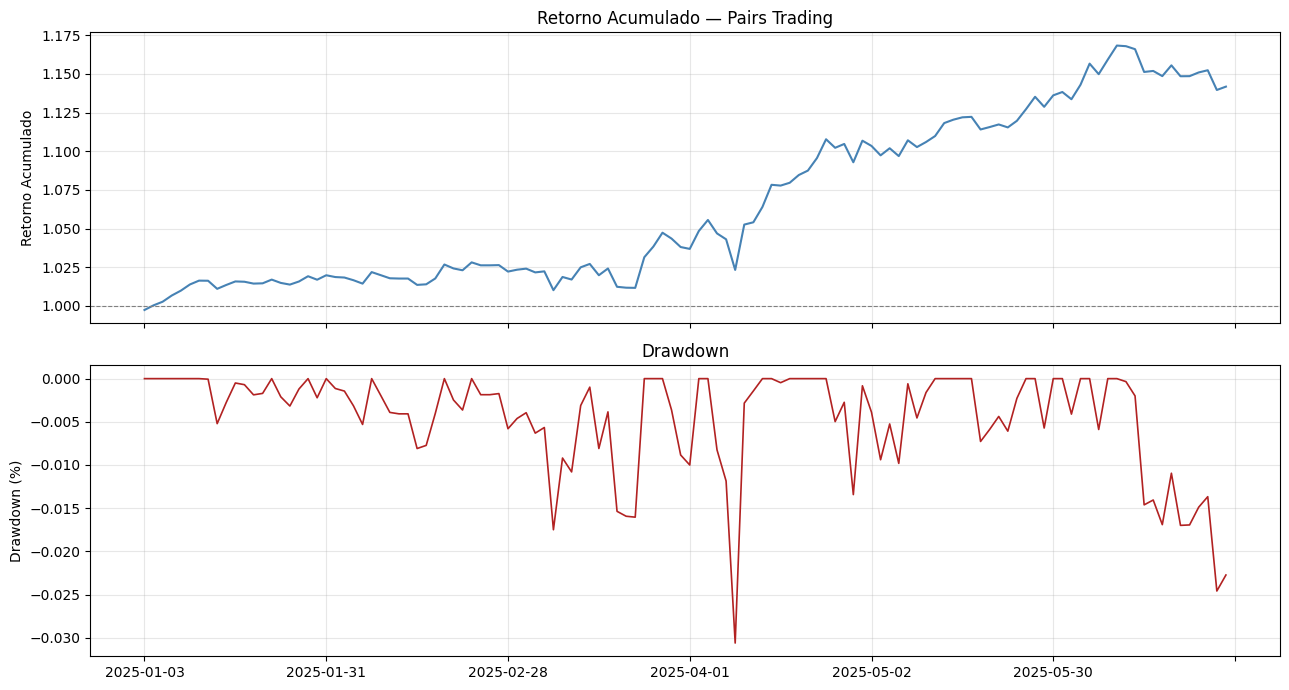

In [17]:
# ── Parâmetros da estratégia ──────────────────────────────────────────────────
ENTRADA   = 2.0
SAIDA     = 0.5
STOP_LOSS = 3.0
CUSTO     = 0.001

# ── Backtest ──────────────────────────────────────────────────────────────────
retornos_diarios = {}

for _, linha in df_pares_validos.iterrows():
    par_nome  = linha['Par']
    at1       = linha['Ativo 1']
    at2       = linha['Ativo 2']
    meia_vida = int(np.ceil(linha['Meia-Vida (Dias Úteis)']))

    col_z    = f"{par_nome}_Z-Score"
    col_beta = f"{par_nome}_Beta_Kalman"

    z    = df_historico_trading[col_z]
    beta = df_historico_trading[col_beta]
    p1   = df_trad[at1]
    p2   = df_trad[at2]

    posicao         = 0
    dias_em_posicao = 0
    retornos_par    = []
    datas           = []

    for i in range(1, len(z)):
        data      = z.index[i]
        z_hoje    = z.iloc[i]
        beta_hoje = beta.iloc[i]

        ret1 = p1.iloc[i] - p1.iloc[i - 1]
        ret2 = p2.iloc[i] - p2.iloc[i - 1]

        # ── Atualiza posição PRIMEIRO ─────────────────────────────────────────
        nova_posicao = posicao

        if posicao == 0:
            if z_hoje >= ENTRADA:
                nova_posicao    = -1
                dias_em_posicao = 0
            elif z_hoje <= -ENTRADA:
                nova_posicao    = +1
                dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje <= -STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo
            elif posicao == -1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje >= STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo

        if nova_posicao != posicao:
            dias_em_posicao = 0

        custo_dia = CUSTO if nova_posicao != posicao else 0.0
        posicao   = nova_posicao

        # ── Calcula retorno DEPOIS de atualizar posição ───────────────────────
        retorno_bruto   = posicao * (ret1 - beta_hoje * ret2)
        retorno_liquido = retorno_bruto - custo_dia

        retornos_par.append(retorno_liquido)
        datas.append(data)

    retornos_diarios[par_nome] = pd.Series(retornos_par, index=datas)

df_retornos = pd.DataFrame(retornos_diarios).fillna(0)

# ── Retorno da carteira com pesos iguais ──────────────────────────────────────
retorno_carteira  = df_retornos.mean(axis=1)
retorno_acumulado = (1 + retorno_carteira).cumprod()
pico              = retorno_acumulado.cummax()
drawdown          = (retorno_acumulado - pico) / pico
mdd               = drawdown.min()
sharpe            = (retorno_carteira.mean() / retorno_carteira.std()) * np.sqrt(252)

# ── Estatísticas ──────────────────────────────────────────────────────────────
print(f"═══ Estatísticas da Estratégia ══════════════════════════════════")
print(f"Pares operados            : {len(df_pares_validos)}")
print(f"Retorno acumulado líquido : {(retorno_acumulado.iloc[-1] - 1) * 100:.2f}%")
print(f"Retorno médio anualizado  : {retorno_carteira.mean() * 252 * 100:.2f}%")
print(f"Volatilidade anualizada   : {retorno_carteira.std() * np.sqrt(252) * 100:.2f}%")
print(f"Sharpe anualizado         : {sharpe:.4f}")
print(f"Maximum Drawdown          : {mdd * 100:.2f}%")

# ── Retorno por par ───────────────────────────────────────────────────────────
retorno_por_par = (1 + df_retornos).prod() - 1
retorno_por_par = retorno_por_par.sort_values()
print(f"\nRetorno acumulado por par:")
print((retorno_por_par * 100).round(2).to_string())
print(f"\nPares lucrativos: {(retorno_por_par > 0).sum()}")
print(f"Pares com perda : {(retorno_por_par < 0).sum()}")

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

retorno_acumulado.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Retorno Acumulado — Pairs Trading')
axes[0].set_ylabel('Retorno Acumulado')
axes[0].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

drawdown.plot(ax=axes[1], color='firebrick', linewidth=1.2)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# ── Exportação dos resultados do Período para Excel ───────────────────────────
ARQUIVO = "periodo_6_jan2024_jun2025.xlsx"

# ── Número total de trades ────────────────────────────────────────────────────
total_trades = 0
for par in df_pares_validos['Par']:
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z = df_historico_trading[col_z]
    posicao = 0
    dias_em_posicao = 0
    meia_vida_par = int(np.ceil(
        df_pares_validos.loc[df_pares_validos['Par'] == par, 'Meia-Vida (Dias Úteis)'].values[0]
    ))
    for z_atual in z:
        nova_posicao = posicao
        if posicao == 0:
            if z_atual >= ENTRADA:
                nova_posicao = -1; dias_em_posicao = 0
            elif z_atual <= -ENTRADA:
                nova_posicao = +1; dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_atual <= SAIDA or z_atual <= -STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
            elif posicao == -1:
                if -SAIDA <= z_atual <= SAIDA or z_atual >= STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
        if nova_posicao == 0 and posicao != 0:
            total_trades += 1
            dias_em_posicao = 0
        posicao = nova_posicao

# ── Aba 5: Estatísticas resumidas ─────────────────────────────────────────────
df_estatisticas = pd.DataFrame([{
    'Período de Estimação'       : 'Jul/2021 – Jun/2022',
    'Período de Trading'         : 'Jul/2022 – Dez/2022',
    'Pares Operados'             : len(df_pares_validos),
    'Total de Trades'            : total_trades,
    'Retorno Acumulado (%)'      : round((retorno_acumulado.iloc[-1] - 1) * 100, 2),
    'Retorno Anualizado (%)'     : round(retorno_carteira.mean() * 252 * 100, 2),
    'Volatilidade Anualizada (%)': round(retorno_carteira.std() * np.sqrt(252) * 100, 2),
    'Sharpe Anualizado'          : round(sharpe, 4),
    'Maximum Drawdown (%)'       : round(mdd * 100, 2),
}])

# ── Aba 4: Retorno diário da carteira + acumulado ─────────────────────────────
df_retorno_carteira = pd.DataFrame({
    'Retorno Diário'    : retorno_carteira,
    'Retorno Acumulado' : retorno_acumulado,
    'Drawdown'          : drawdown,
})

# ── Corrige zeros negativos nos retornos por par ──────────────────────────────
df_retornos_limpo = df_retornos.round(8)

# ── Exporta para Excel com múltiplas abas ─────────────────────────────────────
with pd.ExcelWriter(ARQUIVO, engine='openpyxl') as writer:

    # Aba 1 — Pares selecionados
    df_pares_validos.to_excel(
        writer, sheet_name='1_Pares_Selecionados', index=False)

    # Aba 2 — Z-scores do período de trading
    df_historico_trading[
        [c for c in df_historico_trading.columns if '_Z-Score' in c]
    ].to_excel(writer, sheet_name='2_ZScores_Trading')

    # Aba 3 — Retornos diários por par (sem zeros negativos)
    df_retornos_limpo.to_excel(writer, sheet_name='3_Retornos_Por_Par')

    # Aba 4 — Retorno da carteira
    df_retorno_carteira.to_excel(writer, sheet_name='4_Retorno_Carteira')

    # Aba 5 — Estatísticas resumidas
    df_estatisticas.to_excel(
        writer, sheet_name='5_Estatisticas', index=False)

print(f"Arquivo '{ARQUIVO}' salvo com sucesso!")
print(f"\nAbas geradas:")
print(f"  1_Pares_Selecionados : {len(df_pares_validos)} pares")
print(f"  2_ZScores_Trading    : {len([c for c in df_historico_trading.columns if '_Z-Score' in c])} séries")
print(f"  3_Retornos_Por_Par   : {df_retornos_limpo.shape[1]} pares × {df_retornos_limpo.shape[0]} dias")
print(f"  4_Retorno_Carteira   : {len(df_retorno_carteira)} dias")
print(f"  5_Estatisticas       : {total_trades} trades no período")

Arquivo 'periodo_6_jan2024_jun2025.xlsx' salvo com sucesso!

Abas geradas:
  1_Pares_Selecionados : 6 pares
  2_ZScores_Trading    : 20 séries
  3_Retornos_Por_Par   : 6 pares × 120 dias
  4_Retorno_Carteira   : 120 dias
  5_Estatisticas       : 12 trades no período


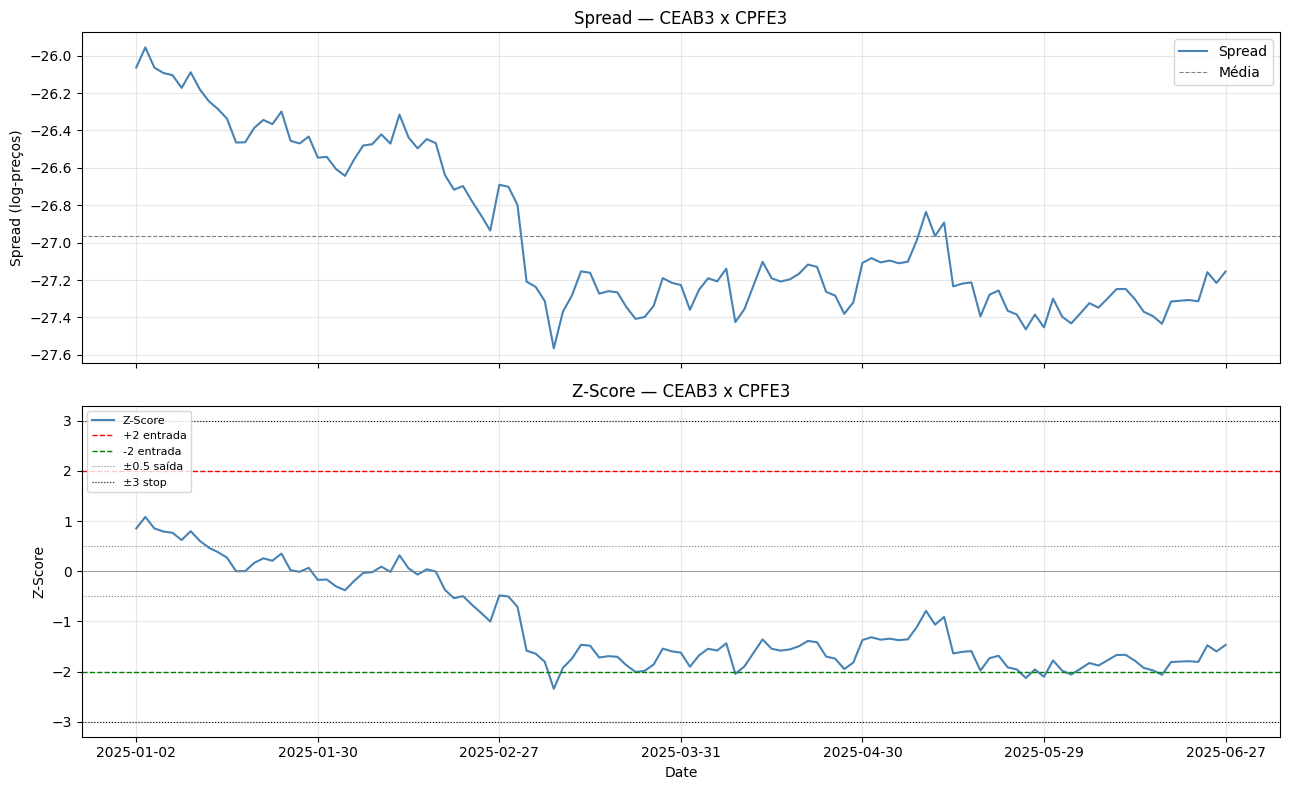

In [23]:
par    = 'CEAB3 x CPFE3'

z      = df_historico_trading[f'{par}_Z-Score']
spread = df_historico_trading[f'{par}_Spread']

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Painel 1 — Spread
spread.plot(ax=axes[0], color='steelblue', linewidth=1.5, label='Spread')
axes[0].axhline(spread.mean(), color='gray', linestyle='--',
                linewidth=0.8, label='Média')
axes[0].set_title(f'Spread — {par}')
axes[0].set_ylabel('Spread (log-preços)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Painel 2 — Z-Score
z.plot(ax=axes[1], color='steelblue', linewidth=1.5, label='Z-Score')

# Linhas de referência
axes[1].axhline( 2.0, color='red',   linestyle='--', linewidth=1,   label='+2 entrada')
axes[1].axhline(-2.0, color='green', linestyle='--', linewidth=1,   label='-2 entrada')
axes[1].axhline( 0.5, color='gray',  linestyle=':',  linewidth=0.8, label='±0.5 saída')
axes[1].axhline(-0.5, color='gray',  linestyle=':',  linewidth=0.8)
axes[1].axhline( 3.0, color='black', linestyle=':',  linewidth=0.8, label='±3 stop')
axes[1].axhline(-3.0, color='black', linestyle=':',  linewidth=0.8)
axes[1].axhline( 0.0, color='gray',  linestyle='-',  linewidth=0.5)

axes[1].set_title(f'Z-Score — {par}')
axes[1].set_ylabel('Z-Score')
axes[1].legend(loc='upper left', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'spread_{par.replace(" x ", "_")}.png', dpi=150, bbox_inches='tight')
plt.show()